# Reproducing the numerical results of Zadeh et al. 2026

Public companion notebook for:

> Zadeh, S. H.; Broucek, J.; Cakirhan, C.; Li, M.; Khatamsaz, D.; Qian, X.;
> Karaman, I.; Arroyave, R. **Bayesian-Optimization-Guided Discovery of
> NiTi(Co,Cu,Pd,Hf,Zr) Multi-Principal Element High-Temperature Shape Memory
> Alloys.** *Acta Materialia* (2026, in review).

This notebook reproduces the three sets of numerical results reported in
Section 3 and Appendix A of the paper, from the tabulated Supplementary
Information alone. It is a rendered version of the three CLI scripts under
`scripts/`; running it end-to-end takes about 30 seconds.

**Prerequisites** (already in `requirements.txt`):
- `numpy`, `pandas`, `scipy`, `openpyxl`, `sympy`, `matplotlib`
- Vendored submodules initialized: `git submodule update --init --recursive`


In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 110, "font.size": 11})

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "scripts"))
DATA = REPO / "data" / "supplementary_data.xlsx"
print(f"Data file exists: {DATA.exists()}   ({DATA.name}, {DATA.stat().st_size // 1024} KB)")


Data file exists: True   (supplementary_data.xlsx, 139 KB)


## 1. Load the supplementary data

The `All Compiled Data` sheet contains one row per (alloy, DSC cycle). We
aggregate to one row per (iteration, unique composition) by taking the
maximum across DSC cycles --- this matches the aggregation used to compute
Table 5.


In [2]:
from compute_spearman_mae import load_dsc_dataframe

df = load_dsc_dataframe(DATA)
print(f"Aggregated {len(df)} rows (one per iteration x unique composition).")
df.head()


Aggregated 87 rows (one per iteration x unique composition).


,Iteration,comp_key,Transforms,Ms (°C),Af (°C),Average Enthalpy (J/g),Predicted Ms (°C),Predicted Af (°C),Predicted Enthalpy (J/g),DT_meas,DT_pred
0,1,45.0|25.0|0|0|5|6|19,0,NaN,NaN,NaN,200.062839,254.795918,7.891569,NaN,54.733079
1,1,36.0|25.0|5|4|5|11|14,0,NaN,NaN,NaN,200.330861,253.652043,5.826405,NaN,53.321182
2,1,43.0|24.0|5|1|1|15|11,1,227.71,260.70,23.190,200.711084,253.515470,8.884908,32.99,52.804386
3,1,32.2|28.8|6|0|12|21|0,1,270.19,321.08,25.647,200.914302,260.804263,5.416531,50.89,59.889961
4,1,39.2|22.8|0|5|6|19|8,1,116.82,183.67,16.501,201.350082,266.081872,5.368055,66.85,64.731790


## 2. Table 5 --- Spearman rank correlation and MAE, per iteration

The Bayesian optimization loop retrains its surrogate with each new round of
MPE observations. As a result, the rank correlation between predicted and
measured M_s rises sharply from Iteration 1 to Iteration 3 --- this is the
central Table 5 finding.


In [3]:
from compute_spearman_mae import summarize

rows = [summarize(df[df["Iteration"] == it], f"Iteration {it}") for it in (1, 2, 3)]
rows.append(summarize(df, "All (Iter 1--3)"))
table5 = pd.DataFrame(rows)
table5[["subset", "N_transforming", "rho_Ms", "mae_Ms", "rho_Af", "mae_Af",
        "rho_DT", "mae_DT", "rho_DH", "mae_DH"]].round(3)


,subset,N_transforming,rho_Ms,mae_Ms,rho_Af,mae_Af,rho_DT,mae_DT,rho_DH,mae_DH
0,Iteration 1,23,0.269,83.907,0.083,85.689,0.090,20.228,0.566,11.577
1,Iteration 2,29,0.269,69.880,0.553,120.083,0.806,55.301,0.713,6.045
2,Iteration 3,29,0.715,44.264,0.750,55.315,0.385,24.630,0.661,4.537
3,All (Iter 1--3),81,0.429,64.692,0.559,87.128,0.568,34.361,0.501,7.267


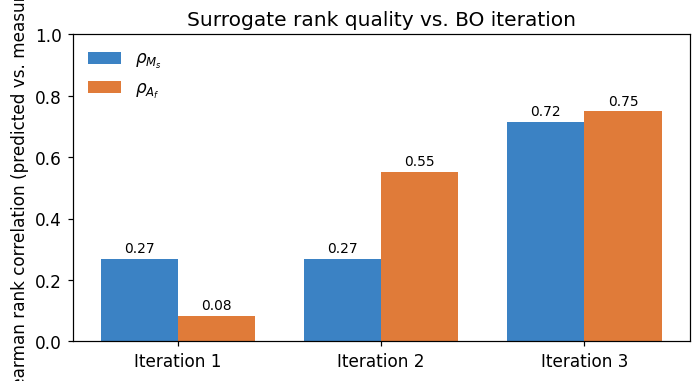

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
its = [1, 2, 3]
rho_Ms = [table5.iloc[i]["rho_Ms"] for i in range(3)]
rho_Af = [table5.iloc[i]["rho_Af"] for i in range(3)]

x = np.arange(len(its))
w = 0.38
ax.bar(x - w/2, rho_Ms, w, label=r"$\rho_{M_s}$", color="#3B82C4")
ax.bar(x + w/2, rho_Af, w, label=r"$\rho_{A_f}$", color="#E07B39")
ax.set_xticks(x)
ax.set_xticklabels([f"Iteration {i}" for i in its])
ax.set_ylim(0, 1)
ax.set_ylabel("Spearman rank correlation (predicted vs. measured)")
ax.set_title("Surrogate rank quality vs. BO iteration")
ax.axhline(0, color="k", lw=0.5)
ax.legend(frameon=False, loc="upper left")
for i, v in enumerate(rho_Ms):
    ax.text(i - w/2, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
for i, v in enumerate(rho_Af):
    ax.text(i + w/2, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


## 3. Appendix A --- per-iteration four-target hit rates

For each iteration, the fraction of alloys that jointly satisfy all four
functional targets:

- $M_s \in [200, 400]\,^{\circ}\text{C}$
- $\Delta T$ (UCFTC) $\leq 50\,^{\circ}\text{C}$
- $\Delta H \geq 20$ J/g
- $\varepsilon_{tr} \geq 2.5$%

Iteration 1's joint pass rate is the calibration point for the Appendix A
attribution analysis.


In [5]:
from compute_four_pass_rates import load_data

merged = load_data(DATA)

hits = []
for it in (1, 2, 3):
    sub = merged[merged["Iteration"] == it]
    trans = sub[sub["Transforms"] == 1]
    n = len(sub)
    ms_hit  = ((trans["Ms (\u00b0C)"] >= 200) & (trans["Ms (\u00b0C)"] <= 400)).sum()
    dt_hit  = ((trans["DT_DSC"] <= 50) & trans["DT_DSC"].notna()).sum()
    dh_hit  = (trans["Average Enthalpy (J/g)"] >= 20).sum()
    eps_hit = (trans["eps_peak"] >= 2.5).sum()
    four = trans[
        (trans["Ms (\u00b0C)"] >= 200) & (trans["Ms (\u00b0C)"] <= 400)
        & (trans["DT_DSC"] <= 50) & trans["DT_DSC"].notna()
        & (trans["Average Enthalpy (J/g)"] >= 20)
        & (trans["eps_peak"] >= 2.5)
    ]
    hits.append({"iter": it, "n": n,
                 "Ms": 100 * ms_hit / n, "DT": 100 * dt_hit / n,
                 "DH": 100 * dh_hit / n, "eps": 100 * eps_hit / n,
                 "4-pass": 100 * len(four) / n})
hits_df = pd.DataFrame(hits)
hits_df.round(1)


,iter,n,Ms,DT,DH,eps,4-pass
0,1,29,41.4,51.7,51.7,24.1,20.7
1,2,29,65.5,69.0,55.2,31.0,27.6
2,3,29,72.4,75.9,79.3,27.6,20.7


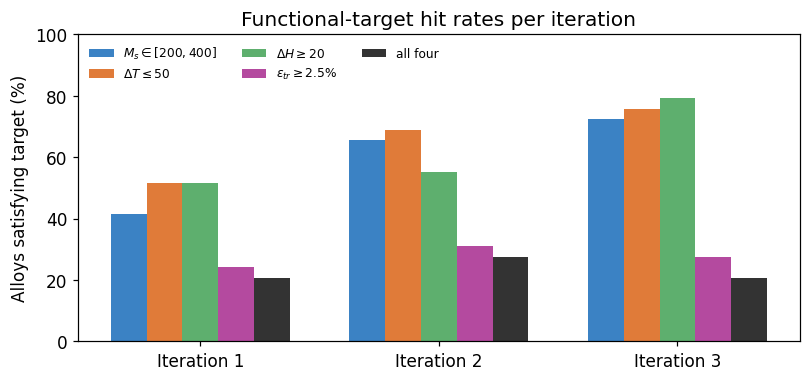

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
targets = ["Ms", "DT", "DH", "eps", "4-pass"]
labels = [r"$M_s \in [200,400]$", r"$\Delta T \leq 50$", r"$\Delta H \geq 20$",
          r"$\varepsilon_{tr} \geq 2.5$%", "all four"]
colors = ["#3B82C4", "#E07B39", "#5EAF6E", "#B44A9F", "#333333"]
x = np.arange(3)
w = 0.15
for j, (t, lab, col) in enumerate(zip(targets, labels, colors)):
    ax.bar(x + (j - 2) * w, hits_df[t], w, label=lab, color=col)
ax.set_xticks(x)
ax.set_xticklabels([f"Iteration {i}" for i in (1, 2, 3)])
ax.set_ylabel("Alloys satisfying target (%)")
ax.set_title("Functional-target hit rates per iteration")
ax.legend(frameon=False, loc="upper left", ncol=3, fontsize=8)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()


## 4. Champion alloy --- crystallographic compatibility and theoretical transformation strain

For the champion alloy $\text{Ni}_{46}\text{Ti}_{28}\text{Hf}_{22}\text{Pd}_2\text{Co}_2$
(and the lowest-hysteresis reference $\text{Ni}_{45}\text{Ti}_{25}\text{Co}_5\text{Hf}_{11}\text{Zr}_{14}$),
we compute:

- **Ball--James geometric compatibility** ($\lambda_1, \lambda_2, \lambda_3$)
  from the measured B2 austenite and B19' martensite lattice parameters, via
  Zadeh et al.'s Phase-Compatibility-Model-NiTi.
- **Theoretical single-crystal transformation strain** ($\varepsilon_{tr}$)
  in five crystallographic directions, via Zadeh et al.'s
  Transformation-Strain-Model-NiTi.

$\lambda_2 \to 1$ is the classic Ball--James condition for low thermal
hysteresis; the champion alloy reaches $\lambda_2 = 0.945$.


In [7]:
from compute_lambda2_eps_tr import ALLOYS, DIRECTIONS, compute_lambdas, compute_eps_tr

PCM = REPO / "vendored" / "Phase-Compatibility-Model-NiTi"
TSM = REPO / "vendored" / "Transformation-Strain-Model-NiTi"

lam_table = []
eps_by_alloy = {}
for label, data in ALLOYS.items():
    lam = compute_lambdas(PCM, data)
    lam_table.append({"alloy": label, **{k: round(v, 4) for k, v in lam.items()}})
    eps_by_alloy[label] = compute_eps_tr(TSM, data)

pd.DataFrame(lam_table)


,alloy,lambda1,lambda2,lambda3
0,Ni46Ti28Co2Pd2Hf22 (champion),0.9212,0.9449,1.1904
1,Ni45Ti25Co5Hf11Zr14 (lowest-DT),0.9197,0.9325,1.1728


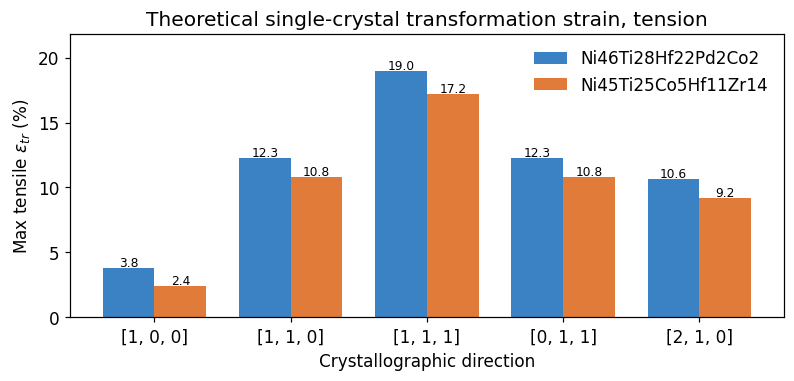

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
alloys = list(eps_by_alloy.keys())
dirs = [str(d) for d in DIRECTIONS]
x = np.arange(len(dirs))
w = 0.38
colors = ["#3B82C4", "#E07B39"]
for k, alloy in enumerate(alloys):
    vals = [eps_by_alloy[alloy][d]["tension_pct"] for d in dirs]
    ax.bar(x + (k - 0.5) * w, vals, w, label=alloy.split(" ")[0], color=colors[k])
ax.set_xticks(x)
ax.set_xticklabels(dirs)
ax.set_ylabel(r"Max tensile $\varepsilon_{tr}$ (%)")
ax.set_xlabel("Crystallographic direction")
ax.set_title("Theoretical single-crystal transformation strain, tension")
ax.legend(frameon=False, loc="upper right")
for k, alloy in enumerate(alloys):
    for i, d in enumerate(dirs):
        v = eps_by_alloy[alloy][d]["tension_pct"]
        ax.text(i + (k - 0.5) * w, v + 0.15, f"{v:.1f}", ha="center", fontsize=8)
ax.set_ylim(0, max(max(eps_by_alloy[a][d]["tension_pct"] for d in dirs) for a in alloys) * 1.15)
plt.tight_layout()
plt.show()


## Citing

If this dataset or notebook is useful to you, please cite the paper (above)
and the vendored submodules whose calculators you exercised.
